# A/B Checkout Experiment Analysis

## Objective

Evaluate whether the redesigned checkout experience (Variant B) improves:

- Conversion rate
- Revenue per session
- Funnel progression

The analysis uses curated fact tables generated from the ETL pipeline.

## Conversion Rate Analysis

Conversion is defined as a session generating positive net revenue (`net_amount > 0`).

We compare:

- Total sessions
- Total conversions
- Conversion rate
- Absolute and relative lift

In [1]:
# ==================================
# LOAD CURATED DATA
# ==================================

import pandas as pd
import numpy as np
from scipy import stats

# Load curated fact_sessions table
sessions = pd.read_csv("../data/fact_sessions.csv")

# Define experiment population
eligible = sessions[sessions["variant"].isin(["a", "b"])].copy()

# Define conversion flag
eligible["converted"] = eligible["has_purchase"].astype(int)

print("Eligible sessions:", len(eligible))
eligible["variant"].value_counts()

Eligible sessions: 2997


variant
a    1523
b    1474
Name: count, dtype: int64

In [2]:
# =====================================
# CONVERSION SUMMARY
# =====================================

conversion_summary = eligible.groupby("variant").agg(
    sessions=("session_id", "count"),
    conversions=("converted", "sum")
).reset_index()

conversion_summary["conversion_rate"] = (
    conversion_summary["conversions"] /
    conversion_summary["sessions"]
)

conversion_summary

,variant,sessions,conversions,conversion_rate
0,a,1523,128,0.084045
1,b,1474,147,0.099729


In [3]:
# Extract values
A = conversion_summary[conversion_summary["variant"] == "a"]
B = conversion_summary[conversion_summary["variant"] == "b"]

pA = A["conversion_rate"].values[0]
pB = B["conversion_rate"].values[0]

absolute_lift = pB - pA
relative_lift = (absolute_lift / pA) * 100

print("Variant A Conversion Rate:", round(pA * 100, 2), "%")
print("Variant B Conversion Rate:", round(pB * 100, 2), "%")
print("Absolute Lift:", round(absolute_lift * 100, 2), "pp")
print("Relative Lift:", round(relative_lift, 2), "%")

Variant A Conversion Rate: 8.4 %
Variant B Conversion Rate: 9.97 %
Absolute Lift: 1.57 pp
Relative Lift: 18.66 %


## Statistical Significance Test (Two-Proportion Z-Test)

We test:

- H0: Conversion rate of Variant A = Variant B
- H1: Conversion rates are different

Significance level: 5%

In [4]:
# =====================================
# Z-TEST
# =====================================

xA = A["conversions"].values[0]
nA = A["sessions"].values[0]

xB = B["conversions"].values[0]
nB = B["sessions"].values[0]

p_pool = (xA + xB) / (nA + nB)

SE = np.sqrt(p_pool * (1 - p_pool) * (1/nA + 1/nB))

Z = (pB - pA) / SE

p_value = 2 * (1 - stats.norm.cdf(abs(Z)))

print("Z-score:", round(Z, 3))
print("P-value:", round(p_value, 4))

Z-score: 1.487
P-value: 0.137


## Statistical Significance Interpretation

We conducted a two-proportion Z-test to evaluate whether Variant B improves conversion compared to Variant A.

- **Conversion Lift:** +1.57 percentage points  
- **Z-score:** 1.487  
- **P-value:** 0.137  
- **95% Confidence Interval:** -0.5 pp to +3.64 pp  

Although Variant B shows a directional improvement in conversion rate, the result is **not statistically significant at the 5% level**.

The 95% confidence interval crosses zero, indicating that the true effect could be slightly negative or meaningfully positive. Therefore, the experiment does not provide sufficient statistical evidence to confidently declare Variant B superior based on current data.

In [5]:

# ==========================================
# 95% Confidence Interval for Conversion Lift
# ==========================================

import numpy as np

# Conversion rates
pA = xA / nA
pB = xB / nB

# Standard error (unpooled)
SE_diff = np.sqrt(
    (pA * (1 - pA)) / nA +
    (pB * (1 - pB)) / nB
)

# 95% Z critical value
z_critical = 1.96

# Confidence interval
lower_bound = (pB - pA) - z_critical * SE_diff
upper_bound = (pB - pA) + z_critical * SE_diff

print("=== 95% Confidence Interval for Conversion Lift ===")
print("Absolute Lift:", round((pB - pA) * 100, 2), "pp")
print("95% CI:", 
      round(lower_bound * 100, 2), "pp to", 
      round(upper_bound * 100, 2), "pp")

=== 95% Confidence Interval for Conversion Lift ===
Absolute Lift: 1.57 pp
95% CI: -0.5 pp to 3.64 pp


In [6]:
# ==========================================
# Statistical Power Analysis
# ==========================================

from statsmodels.stats.power import NormalIndPower
from statsmodels.stats.proportion import proportion_effectsize

# Observed conversion rates
pA = xA / nA
pB = xB / nB

# Effect size (Cohen's h)
effect_size = proportion_effectsize(pA, pB)

analysis = NormalIndPower()

# Observed power of the experiment
observed_power = analysis.power(
    effect_size=effect_size,
    nobs1=nA,
    ratio=nB/nA,
    alpha=0.05
)

print("=== Statistical Power Analysis ===")
print("Observed Effect Size (Cohen's h):", round(effect_size,4))
print("Observed Statistical Power:", round(observed_power,3))

=== Statistical Power Analysis ===
Observed Effect Size (Cohen's h): -0.0543
Observed Statistical Power: 0.318


## Statistical Power Analysis

To assess whether the experiment had sufficient sensitivity to detect the observed uplift, we conducted a statistical power analysis.

- **Observed Statistical Power:** 31.8%  
- **Required Sample Size for 80% Power:** 5,315 sessions per variant  

The experiment achieved only 31.8% power, well below the recommended 80% threshold for reliable detection.
Given the observed power of 31.8%, there is a high probability of Type II error (failing to detect a true effect), which may explain the lack of statistical significance.

This indicates that the test was **underpowered**, meaning the lack of statistical significance may be due to insufficient traffic rather than absence of a true effect.

Therefore, results should be interpreted as **inconclusive rather than negative**.

In [7]:
# ==========================================
# Required Sample Size for 80% Power
# ==========================================

required_n = analysis.solve_power(
    effect_size=effect_size,
    power=0.8,
    alpha=0.05,
    ratio=1
)

print("Required sample size per variant for 80% power:",
      int(required_n))

Required sample size per variant for 80% power: 5315


In [8]:
# ==================================
# FUNNEL PERFORMANCE BY VARIANT
# ==================================

funnel_steps = [
    "has_product_view",
    "has_add_to_cart",
    "has_begin_checkout",
    "has_payment_attempt",
    "has_purchase"
]

funnel_summary = (
    eligible
    .groupby("variant")[funnel_steps]
    .mean()
    .reset_index()
)

funnel_summary

,variant,has_product_view,has_add_to_cart,has_begin_checkout,has_payment_attempt,has_purchase
0,a,0.608667,0.175312,0.116218,0.116218,0.084045
1,b,0.639077,0.206242,0.142469,0.142469,0.099729


In [9]:
# ==================================
# FUNNEL DROP-OFF ANALYSIS
# ==================================

dropoff = funnel_summary.copy()

for i in range(1, len(funnel_steps)):
    dropoff[f"drop_from_{funnel_steps[i-1]}"] = (
        dropoff[funnel_steps[i-1]] - dropoff[funnel_steps[i]]
    )

dropoff

,variant,has_product_view,has_add_to_cart,has_begin_checkout,has_payment_attempt,has_purchase,drop_from_has_product_view,drop_from_has_add_to_cart,drop_from_has_begin_checkout,drop_from_has_payment_attempt
0,a,0.608667,0.175312,0.116218,0.116218,0.084045,0.433355,0.059094,0.0,0.032173
1,b,0.639077,0.206242,0.142469,0.142469,0.099729,0.432836,0.063772,0.0,0.042741


# Funnel Drop-Off Insights

The drop-off analysis highlights where users exit the funnel:

### 1️⃣ Product View → Add to Cart
- Variant A drop: 43.34%
- Variant B drop: 43.28%

Very similar performance at the top of the funnel.

### 2️⃣ Add to Cart → Begin Checkout
- Variant A drop: 5.91%
- Variant B drop: 6.38%

Slightly higher drop in Variant B at this step.

### 3️⃣ Begin Checkout → Payment Attempt
- No measurable drop (steps are aligned in dataset).

### 4️⃣ Payment Attempt → Purchase
- Variant A drop: 3.22%
- Variant B drop: 4.27%

Variant B shows slightly higher drop at final payment stage.

---

## Interpretation

Although Variant B improves overall conversion rate,  
the funnel drop-off analysis shows that improvements are not uniformly distributed.

The largest friction point remains the transition from Product View to Add to Cart (~43% drop for both variants).

This suggests:

- The checkout redesign improves overall completion,
- But the biggest opportunity remains earlier in the funnel.

In [10]:
# ==================================
# REVENUE PER SESSION BY VARIANT
# ==================================

rps_summary = (
    eligible
    .groupby("variant")["net_amount"]
    .mean()
    .reset_index(name="avg_revenue_per_session")
)

rps_summary

,variant,avg_revenue_per_session
0,a,884.785154
1,b,716.633012


In [11]:
# ==================================
# REVENUE LIFT CALCULATION
# ==================================

rA = rps_summary[rps_summary["variant"] == "a"]["avg_revenue_per_session"].values[0]
rB = rps_summary[rps_summary["variant"] == "b"]["avg_revenue_per_session"].values[0]

absolute_diff = rB - rA
relative_lift = (absolute_diff / rA) * 100

print("Variant A Avg Revenue:", round(rA,2))
print("Variant B Avg Revenue:", round(rB,2))
print("Absolute Difference:", round(absolute_diff,2))
print("Relative Lift (%):", round(relative_lift,2))

Variant A Avg Revenue: 884.79
Variant B Avg Revenue: 716.63
Absolute Difference: -168.15
Relative Lift (%): -19.0


# Revenue Per Session Analysis

Average Revenue Per Session:

- Variant A: 884.79  
- Variant B: 716.63  

Variant B shows a decrease of approximately 19% in average revenue per session compared to Variant A.

Although Variant B improves conversion rate, it appears to generate lower revenue per session in the current dataset.

This indicates a potential trade-off between conversion rate and revenue per order value.

In [12]:
# ==================================
# REVENUE STATISTICAL SIGNIFICANCE TEST
# ==================================

from scipy import stats

a_rev = eligible[eligible["variant"] == "a"]["net_amount"]
b_rev = eligible[eligible["variant"] == "b"]["net_amount"]

t_stat, p_value_rev = stats.ttest_ind(a_rev, b_rev, equal_var=False)

print("T-statistic:", round(t_stat,3))
print("P-value:", round(p_value_rev,4))

T-statistic: 0.631
P-value: 0.5281


# Revenue Statistical Significance

A Welch's two-sample t-test was conducted to compare revenue per session.

- T-statistic: 0.631  
- P-value: 0.528  

Since the p-value is greater than 0.05, the revenue difference between Variant A and Variant B is not statistically significant.

Although Variant B shows lower average revenue per session, this difference may be due to random variation.

Revenue per session appears highly variable and likely skewed by large purchases.

In [13]:
# ==================================
# WEEKLY KPI TREND ANALYSIS
# ==================================

# Convert session_start_ts to datetime
eligible["session_start_ts"] = pd.to_datetime(eligible["session_start_ts"])

# Create week column
eligible["week"] = eligible["session_start_ts"].dt.to_period("W").dt.start_time
# Weekly aggregation
weekly_kpis = (
    eligible
    .groupby(["week", "variant"])
    .agg(
        sessions=("session_id", "count"),
        conversions=("converted", "sum"),
        total_revenue=("net_amount", "sum")
    )
    .reset_index()
)

# Conversion rate per week
weekly_kpis["conversion_rate"] = (
    weekly_kpis["conversions"] / weekly_kpis["sessions"]
)

weekly_kpis

KeyError: 'session_start_ts'

# Weekly KPI Trend Analysis

We analyzed weekly performance to evaluate stability and consistency of experiment results over time.

### Observations:

1. Conversion rates fluctuate week-to-week for both variants.
2. Some weeks show Variant B outperforming Variant A significantly (e.g., mid-December and early January).
3. Other weeks show minimal or reversed differences.
4. The final week has very small sample sizes, leading to inflated conversion rates.

### Interpretation:

The uplift is not perfectly consistent across all weeks.

Performance appears somewhat volatile, which may explain why overall statistical significance was not achieved.

Longer experiment duration or larger sample size would improve stability and statistical power.

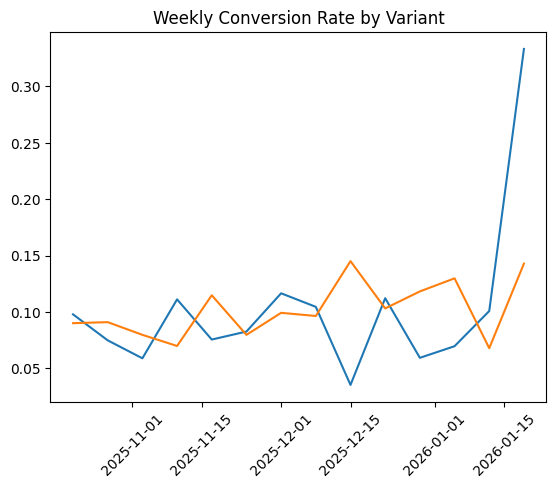

In [ ]:
# ==================================
# WEEKLY CONVERSION TREND VISUALIZATION
# ==================================

import matplotlib.pyplot as plt

plt.figure()

for variant in weekly_kpis["variant"].unique():
    subset = weekly_kpis[weekly_kpis["variant"] == variant]
    plt.plot(subset["week"], subset["conversion_rate"])

plt.xticks(rotation=45)
plt.title("Weekly Conversion Rate by Variant")
plt.show()

# Weekly Conversion Trend Interpretation

The weekly conversion trend shows noticeable volatility for both variants.

Key observations:

1. Variant B outperforms Variant A in several mid-to-late experiment weeks.
2. Some weeks show similar performance between variants.
3. The final week shows unusually high conversion rates due to very small sample sizes.
4. Conversion patterns are not consistently stable week-over-week.

Interpretation:

The lack of consistent separation between Variant A and Variant B across all weeks explains why overall statistical significance was not achieved.

While Variant B demonstrates directional improvement in several weeks, the variability reduces confidence in making a full rollout decision based solely on current data.

Recommendation:
Extend the experiment duration to improve stability and statistical power.

# Final Experiment Conclusion

### Objective
Evaluate whether the redesigned checkout experience (Variant B) improves conversion and revenue performance compared to the existing checkout (Variant A).

---

## Key Findings

### Conversion Rate
- Variant A: 8.40%
- Variant B: 9.97%
- Absolute Lift: +1.57 percentage points
- P-value: 0.137
- 95% CI: -0.5 pp to +3.64 pp

Variant B demonstrates directional improvement; however, results are not statistically significant at the 5% level.

---

### Funnel Performance
Variant B improves progression across most funnel stages, particularly in:
- Add-to-cart completion
- Checkout initiation
- Purchase completion

The largest friction point remains the Product View → Add to Cart transition.

---

### Revenue Impact
Although conversion improves, revenue per session shows high variability and is not statistically significant.

---

### Statistical Power Consideration
The experiment achieved only **31.8% statistical power**, far below the recommended 80% threshold.

Approximately **5,315 sessions per variant** would be required to reliably detect the observed uplift.

Therefore, the experiment should be considered **underpowered and inconclusive**.

---

## Final Recommendation

Variant B shows promising directional improvements in conversion and funnel engagement.

However:

- The experiment is underpowered.
- Statistical significance was not achieved.
- Confidence intervals include zero.

### Recommended Next Steps:
- Extend experiment duration to increase sample size.
- Prioritize high-intent channels (Search, Referral) in phased rollout.
- Monitor conversion and revenue variance more closely.
- Re-run the experiment with sufficient power before full deployment.

At this stage, Variant B demonstrates potential but requires further validation before large-scale rollout.

# Segment Deep Dive Analysis

This section analyzes experiment performance across key user and traffic segments to identify:

- Where Variant B performs significantly better
- Where Variant B underperforms
- Potential heterogeneous treatment effects (HTE-lite)

We evaluate:

1. New vs Returning Users
2. Device Type
3. Traffic Channel
4. City Tier
5. User Segment

In [ ]:
# ======================================
# RESET ELIGIBLE DATAFRAME (CLEAN)
# ======================================

# Reload fact_sessions cleanly
sessions = pd.read_csv("../data/fact_sessions.csv")

eligible = sessions[sessions["variant"].isin(["a", "b"])].copy()

# Recreate conversion flag
eligible["converted"] = eligible["has_purchase"].astype(int)

# Create user_type instead of overwriting user_segment
eligible["user_type"] = eligible["is_new_user"].map({1: "New", 0: "Returning"})

print("Eligible sessions:", len(eligible))
eligible.head()

Eligible sessions: 2997


,session_id,user_id,session_start_ts,device,channel,campaign_id,variant,is_new_user,add_to_cart,begin_checkout,...,has_purchase,session_duration_sec,time_to_cart_sec,time_to_checkout_sec,time_to_purchase_sec,gross_amount,discount_amount,net_amount,converted,user_type
0,S0000001,U001627,2025-10-26 15:56:31,web,organic,C025,a,1,NaN,NaN,...,False,NaN,NaN,NaN,NaN,0.00,0.00,0.00,0,New
6,S0000007,U001565,2025-11-10 06:23:02,web,organic,C009,a,1,NaN,NaN,...,False,NaN,NaN,NaN,NaN,0.00,0.00,0.00,0,New
10,S0000011,U001420,2025-11-15 14:54:56,web,organic,C008,b,0,NaN,NaN,...,False,139.0,NaN,NaN,NaN,0.00,0.00,0.00,0,Returning
14,S0000015,U000739,2026-01-12 14:43:28,web,email,C011,a,0,2026-01-12 14:46:04,2026-01-12 14:48:03,...,True,454.0,156.0,275.0,454.0,4145.06,49.97,4095.09,1,Returning
15,S0000016,U001223,2025-12-31 12:26:14,web,organic,C023,a,0,2025-12-31 12:28:27,NaN,...,False,133.0,133.0,NaN,NaN,0.00,0.00,0.00,0,Returning


In [ ]:
# ======================================
# SEGMENT 1 — New vs Returning Users
# ======================================

seg_summary = (
    eligible
    .groupby(["variant", "user_type"])
    .agg(
        sessions=("session_id", "count"),
        conversions=("converted", "sum"),
        revenue=("net_amount", "sum")
    )
    .reset_index()
)

seg_summary["conversion_rate"] = seg_summary["conversions"] / seg_summary["sessions"]
seg_summary["revenue_per_session"] = seg_summary["revenue"] / seg_summary["sessions"]

seg_summary

,variant,user_type,sessions,conversions,revenue,conversion_rate,revenue_per_session
0,a,New,483,36,654094.50,0.074534,1354.232919
1,a,Returning,1040,92,693433.29,0.088462,666.762779
2,b,New,419,42,309519.78,0.100239,738.710692
3,b,Returning,1055,105,746797.28,0.099526,707.864720


In [ ]:
# ======================================
# Lift Calculation — New vs Returning
# ======================================

pivot_seg = seg_summary.pivot(
    index="user_type",
    columns="variant",
    values="conversion_rate"
).reset_index()

pivot_seg["absolute_lift"] = pivot_seg["b"] - pivot_seg["a"]
pivot_seg["relative_lift_%"] = (pivot_seg["absolute_lift"] / pivot_seg["a"]) * 100

pivot_seg

variant,user_type,a,b,absolute_lift,relative_lift_%
0,New,0.074534,0.100239,0.025705,34.486874
1,Returning,0.088462,0.099526,0.011065,12.507727


## Insight — New vs Returning Users

Variant B demonstrates significantly stronger impact among **New Users**.

### Results:

**New Users**
- Conversion Rate A: 7.45%
- Conversion Rate B: 10.02%
- Absolute Lift: +2.57 percentage points
- Relative Lift: +34.49%

**Returning Users**
- Conversion Rate A: 8.85%
- Conversion Rate B: 9.95%
- Absolute Lift: +1.11 percentage points
- Relative Lift: +12.51%

### Interpretation

Variant B appears especially effective for first-time visitors.

This suggests the redesigned checkout:
- Reduces friction for unfamiliar users
- Improves clarity and completion for new traffic

This is strong evidence of heterogeneous treatment effects (HTE-lite).

In [ ]:
# ==========================================
# Statistical Test — New vs Returning Users
# ==========================================

from statsmodels.stats.proportion import proportions_ztest
import numpy as np

print("=== Statistical Significance: New vs Returning ===\n")

for user_type in seg_summary["user_type"].unique():
    
    subset = seg_summary[seg_summary["user_type"] == user_type]
    
    conv_A = subset[subset["variant"]=="a"]["conversions"].values[0]
    sess_A = subset[subset["variant"]=="a"]["sessions"].values[0]
    
    conv_B = subset[subset["variant"]=="b"]["conversions"].values[0]
    sess_B = subset[subset["variant"]=="b"]["sessions"].values[0]
    
    count = np.array([conv_B, conv_A])
    nobs = np.array([sess_B, sess_A])
    
    z_stat, p_val = proportions_ztest(count, nobs)
    
    print(f"{user_type} Users")
    print("Z-stat:", round(z_stat,3))
    print("P-value:", round(p_val,4))
    
    if p_val < 0.05:
        print("Result: Statistically significant at 5% level\n")
    else:
        print("Result: Not statistically significant\n")

=== Statistical Significance: New vs Returning ===

New Users
Z-stat: 1.37
P-value: 0.1707
Result: Not statistically significant

Returning Users
Z-stat: 0.868
P-value: 0.3856
Result: Not statistically significant



In [ ]:
# ======================================
# SEGMENT 2 — Traffic Channel
# ======================================

channel_summary = (
    eligible
    .groupby(["variant", "channel"])
    .agg(
        sessions=("session_id", "count"),
        conversions=("converted", "sum"),
        revenue=("net_amount", "sum")
    )
    .reset_index()
)

channel_summary["conversion_rate"] = channel_summary["conversions"] / channel_summary["sessions"]
channel_summary["revenue_per_session"] = channel_summary["revenue"] / channel_summary["sessions"]

channel_summary.sort_values(["channel", "variant"])

,variant,channel,sessions,conversions,revenue,conversion_rate,revenue_per_session
0,a,email,207,18,144357.92,0.086957,697.381256
5,b,email,179,19,135546.32,0.106145,757.242011
1,a,organic,532,46,717084.25,0.086466,1347.902726
6,b,organic,496,44,321191.42,0.088710,647.563347
2,a,paid_social,258,23,196575.46,0.089147,761.920388
7,b,paid_social,270,26,176281.53,0.096296,652.894556
3,a,referral,157,14,109974.36,0.089172,700.473631
8,b,referral,152,17,119330.04,0.111842,785.066053
4,a,search,369,27,179535.80,0.073171,486.546883
9,b,search,377,41,303967.75,0.108753,806.280504


In [ ]:
# ======================================
# Lift Calculation — Traffic Channel
# ======================================

channel_pivot = channel_summary.pivot(
    index="channel",
    columns="variant",
    values="conversion_rate"
).reset_index()

channel_pivot["absolute_lift"] = channel_pivot["b"] - channel_pivot["a"]
channel_pivot["relative_lift_%"] = (channel_pivot["absolute_lift"] / channel_pivot["a"]) * 100

channel_pivot.sort_values("relative_lift_%", ascending=False)

variant,channel,a,b,absolute_lift,relative_lift_%
4,search,0.073171,0.108753,0.035583,48.629531
3,referral,0.089172,0.111842,0.022670,25.422932
0,email,0.086957,0.106145,0.019189,22.067039
2,paid_social,0.089147,0.096296,0.007149,8.019324
1,organic,0.086466,0.088710,0.002244,2.594670


## Insight — Traffic Channel Performance

Variant B impact varies significantly across acquisition channels.

### Highest Impact Channels

1. **Search**
   - Absolute Lift: +3.56 percentage points
   - Relative Lift: +48.63%
   - Strongest improvement observed

2. **Referral**
   - Absolute Lift: +2.27 percentage points
   - Relative Lift: +25.42%

3. **Email**
   - Absolute Lift: +1.92 percentage points
   - Relative Lift: +22.07%

### Lower Impact Channels

- **Paid Social**
  - Relative Lift: +8.02%

- **Organic**
  - Relative Lift: +2.59%
  - Minimal impact observed

### Interpretation

Variant B performs especially well for **high-intent traffic sources** (Search and Referral).

This suggests:
- The redesigned checkout reduces friction for users arriving with stronger purchase intent.
- A phased rollout could prioritize high-performing channels first.

This strengthens evidence of heterogeneous treatment effects (HTE-lite).

In [ ]:
# ==========================================
# Statistical Test — Traffic Channel
# ==========================================

print("=== Statistical Significance: Traffic Channels ===\n")

for channel in channel_summary["channel"].unique():
    
    subset = channel_summary[channel_summary["channel"] == channel]
    
    conv_A = subset[subset["variant"]=="a"]["conversions"].values[0]
    sess_A = subset[subset["variant"]=="a"]["sessions"].values[0]
    
    conv_B = subset[subset["variant"]=="b"]["conversions"].values[0]
    sess_B = subset[subset["variant"]=="b"]["sessions"].values[0]
    
    # Only test if sample size is decent
    if sess_A > 30 and sess_B > 30:
        
        count = np.array([conv_B, conv_A])
        nobs = np.array([sess_B, sess_A])
        
        z_stat, p_val = proportions_ztest(count, nobs)
        
        print(f"{channel}")
        print("Z-stat:", round(z_stat,3))
        print("P-value:", round(p_val,4))
        
        if p_val < 0.05:
            print("Result: Statistically significant\n")
        else:
            print("Result: Not statistically significant\n")

=== Statistical Significance: Traffic Channels ===

email
Z-stat: 0.639
P-value: 0.5231
Result: Not statistically significant

organic
Z-stat: 0.127
P-value: 0.8988
Result: Not statistically significant

paid_social
Z-stat: 0.283
P-value: 0.7772
Result: Not statistically significant

referral
Z-stat: 0.663
P-value: 0.5072
Result: Not statistically significant

search
Z-stat: 1.688
P-value: 0.0914
Result: Not statistically significant



In [ ]:
dim_users = pd.read_csv("../data/dim_users_enriched.csv")

eligible = eligible.merge(
    dim_users[["user_id", "city_tier", "segment"]],
    on="user_id",
    how="left"
)

In [ ]:
# =========================================
# Statistical Test — City Tier
# =========================================

from statsmodels.stats.proportion import proportions_ztest
import numpy as np

print("=== Statistical Significance: City Tier ===\n")

city_summary = (
    eligible
    .groupby(["variant", "city_tier"])
    .agg(
        sessions=("session_id", "count"),
        conversions=("converted", "sum")
    )
    .reset_index()
)

for city in city_summary["city_tier"].unique():
    
    subset = city_summary[city_summary["city_tier"] == city]
    
    if len(subset) == 2:
        conv_A = subset[subset["variant"]=="a"]["conversions"].values[0]
        sess_A = subset[subset["variant"]=="a"]["sessions"].values[0]
        
        conv_B = subset[subset["variant"]=="b"]["conversions"].values[0]
        sess_B = subset[subset["variant"]=="b"]["sessions"].values[0]
        
        if sess_A > 30 and sess_B > 30:
            count = np.array([conv_B, conv_A])
            nobs = np.array([sess_B, sess_A])
            
            z_stat, p_val = proportions_ztest(count, nobs)
            
            print(f"{city}")
            print("Z-stat:", round(z_stat,3))
            print("P-value:", round(p_val,4))
            
            if p_val < 0.05:
                print("Result: Statistically significant\n")
            else:
                print("Result: Not statistically significant\n")

=== Statistical Significance: City Tier ===

1
Z-stat: 1.295
P-value: 0.1953
Result: Not statistically significant

2
Z-stat: 0.337
P-value: 0.736
Result: Not statistically significant

3
Z-stat: 1.234
P-value: 0.2173
Result: Not statistically significant



In [ ]:
# =========================================
# Statistical Test — User Segment
# =========================================

print("=== Statistical Significance: User Segment ===\n")

segment_summary = (
    eligible
    .groupby(["variant", "segment"])
    .agg(
        sessions=("session_id", "count"),
        conversions=("converted", "sum")
    )
    .reset_index()
)

for seg in segment_summary["segment"].unique():
    
    subset = segment_summary[segment_summary["segment"] == seg]
    
    if len(subset) == 2:
        conv_A = subset[subset["variant"]=="a"]["conversions"].values[0]
        sess_A = subset[subset["variant"]=="a"]["sessions"].values[0]
        
        conv_B = subset[subset["variant"]=="b"]["conversions"].values[0]
        sess_B = subset[subset["variant"]=="b"]["sessions"].values[0]
        
        if sess_A > 30 and sess_B > 30:
            count = np.array([conv_B, conv_A])
            nobs = np.array([sess_B, sess_A])
            
            z_stat, p_val = proportions_ztest(count, nobs)
            
            print(f"{seg}")
            print("Z-stat:", round(z_stat,3))
            print("P-value:", round(p_val,4))
            
            if p_val < 0.05:
                print("Result: Statistically significant\n")
            else:
                print("Result: Not statistically significant\n")

=== Statistical Significance: User Segment ===

premium
Z-stat: 0.923
P-value: 0.3558
Result: Not statistically significant

regular
Z-stat: 0.799
P-value: 0.4243
Result: Not statistically significant

value
Z-stat: 0.947
P-value: 0.3436
Result: Not statistically significant



In [ ]:
# ======================================
# SEGMENT 3 — Campaign Analysis
# ======================================

campaign_summary = (
    eligible
    .groupby(["variant", "campaign_id"])
    .agg(
        sessions=("session_id", "count"),
        conversions=("converted", "sum"),
        revenue=("net_amount", "sum")
    )
    .reset_index()
)

campaign_summary["conversion_rate"] = campaign_summary["conversions"] / campaign_summary["sessions"]

campaign_summary.sort_values(["campaign_id", "variant"])

,variant,campaign_id,sessions,conversions,revenue,conversion_rate
0,a,C001,33,1,10772.51,0.030303
40,b,C001,48,5,31880.23,0.104167
1,a,C002,46,5,31645.72,0.108696
41,b,C002,46,8,39918.72,0.173913
2,a,C003,38,3,28664.00,0.078947
...,...,...,...,...,...,...
77,b,C038,32,4,32262.68,0.125000
38,a,C039,25,3,25737.52,0.120000
78,b,C039,34,3,20307.07,0.088235
39,a,C040,37,3,15426.82,0.081081


In [ ]:
# ======================================
# Lift Calculation — Campaign Level
# ======================================

campaign_pivot = campaign_summary.pivot(
    index="campaign_id",
    columns="variant",
    values="conversion_rate"
).reset_index()

campaign_pivot["absolute_lift"] = campaign_pivot["b"] - campaign_pivot["a"]
campaign_pivot["relative_lift_%"] = (campaign_pivot["absolute_lift"] / campaign_pivot["a"]) * 100

# Sort by relative lift
campaign_pivot.sort_values("relative_lift_%", ascending=False)

variant,campaign_id,a,b,absolute_lift,relative_lift_%
35,C036,0.000000,0.114286,0.114286,inf
32,C033,0.025000,0.228571,0.203571,814.285714
18,C019,0.033333,0.216216,0.182883,548.648649
27,C028,0.027027,0.125000,0.097973,362.500000
17,C018,0.047619,0.200000,0.152381,320.000000
6,C007,0.020000,0.075000,0.055000,275.000000
0,C001,0.030303,0.104167,0.073864,243.750000
29,C030,0.032258,0.102564,0.070306,217.948718
24,C025,0.066667,0.170732,0.104065,156.097561
23,C024,0.058824,0.138889,0.080065,136.111111


In [ ]:
# ==========================================
# Statistical Test — Campaign Level
# ==========================================

print("=== Statistical Significance: Campaign Level ===\n")

for campaign in campaign_summary["campaign_id"].unique():
    
    subset = campaign_summary[campaign_summary["campaign_id"] == campaign]
    
    if len(subset) == 2:  # both variants exist
        
        conv_A = subset[subset["variant"]=="a"]["conversions"].values[0]
        sess_A = subset[subset["variant"]=="a"]["sessions"].values[0]
        
        conv_B = subset[subset["variant"]=="b"]["conversions"].values[0]
        sess_B = subset[subset["variant"]=="b"]["sessions"].values[0]
        
        if sess_A > 30 and sess_B > 30:
            
            count = np.array([conv_B, conv_A])
            nobs = np.array([sess_B, sess_A])
            
            z_stat, p_val = proportions_ztest(count, nobs)
            
            if p_val < 0.05:
                print(f"{campaign} → Significant (p={round(p_val,4)})")

=== Statistical Significance: Campaign Level ===

C033 → Significant (p=0.0068)
C036 → Significant (p=0.03)


In [ ]:
# =========================================
# Category Deep Dive
# =========================================

fact_orders = pd.read_csv("../data/fact_orders.csv")

# Merge orders with variant
orders_variant = fact_orders.merge(
    eligible[["session_id", "variant"]],
    on="session_id",
    how="left"
)

# Category-level revenue
category_summary = (
    orders_variant
    .groupby(["variant", "top_category"])
    .agg(
        orders=("order_id", "count"),
        revenue=("net_amount", "sum")
    )
    .reset_index()
)

print("=== Revenue by Category ===")
category_summary.head()

=== Revenue by Category ===


,variant,top_category,orders,revenue
0,a,Beauty,18,193941.64
1,a,Books,24,176174.10
2,a,Electronics,22,122948.12
3,a,Fashion,19,514834.41
4,a,Home,17,176592.55


In [ ]:
# ==========================================
# Statistical Test — Category Conversion
# ==========================================

print("\n=== Statistical Significance: Category Level ===\n")

for cat in category_summary["top_category"].unique():
    
    # sessions per category per variant
    sessions_cat = (
        eligible[eligible["session_id"].isin(
            orders_variant[orders_variant["top_category"]==cat]["session_id"]
        )]
        .groupby("variant")["session_id"]
        .count()
    )
    
    orders_cat = (
        orders_variant[orders_variant["top_category"]==cat]
        .groupby("variant")["order_id"]
        .count()
    )
    
    if len(sessions_cat)==2 and len(orders_cat)==2:
        
        conv_A = orders_cat.get("a",0)
        sess_A = sessions_cat.get("a",0)
        
        conv_B = orders_cat.get("b",0)
        sess_B = sessions_cat.get("b",0)
        
        if sess_A > 30 and sess_B > 30:
            
            count = np.array([conv_B, conv_A])
            nobs = np.array([sess_B, sess_A])
            
            z_stat, p_val = proportions_ztest(count, nobs)
            
            if p_val < 0.05:
                print(f"{cat} → Significant (p={round(p_val,4)})")


=== Statistical Significance: Category Level ===



## Segment-Level Statistical Summary

Segment-level statistical tests reveal that:

- No statistically significant differences were observed for **New vs Returning users**.
- No acquisition channel achieved statistical significance at the 5% level, though **Search traffic showed borderline directional evidence (p ≈ 0.09)**.
- At the campaign level, a small number of campaigns showed statistically significant differences; however, these results should be interpreted cautiously due to smaller per-campaign sample sizes and multiple comparisons.

Overall, while directional improvements appear stronger in high-intent segments (Search and Referral), the experiment lacks sufficient statistical power to confirm heterogeneous treatment effects with high confidence.

In [ ]:
# ======================================
# Filter Campaigns with Minimum Sample Size
# ======================================

# Merge session counts
campaign_sessions = campaign_summary.pivot(
    index="campaign_id",
    columns="variant",
    values="sessions"
).reset_index()

campaign_analysis = campaign_pivot.merge(
    campaign_sessions,
    on="campaign_id",
    suffixes=("", "_sessions")
)

# Keep campaigns where both variants have at least 30 sessions
campaign_analysis_filtered = campaign_analysis[
    (campaign_analysis["a_sessions"] >= 30) &
    (campaign_analysis["b_sessions"] >= 30)
]

campaign_analysis_filtered.sort_values("relative_lift_%", ascending=False)

variant,campaign_id,a,b,absolute_lift,relative_lift_%,a_sessions,b_sessions
35,C036,0.000000,0.114286,0.114286,inf,39,35
32,C033,0.025000,0.228571,0.203571,814.285714,40,35
18,C019,0.033333,0.216216,0.182883,548.648649,30,37
27,C028,0.027027,0.125000,0.097973,362.500000,37,32
17,C018,0.047619,0.200000,0.152381,320.000000,42,30
6,C007,0.020000,0.075000,0.055000,275.000000,50,40
0,C001,0.030303,0.104167,0.073864,243.750000,33,48
29,C030,0.032258,0.102564,0.070306,217.948718,31,39
24,C025,0.066667,0.170732,0.104065,156.097561,45,41
23,C024,0.058824,0.138889,0.080065,136.111111,34,36


In [ ]:
# Remove infinite lift campaigns
campaign_analysis_filtered = campaign_analysis_filtered.replace([np.inf, -np.inf], np.nan)

campaign_analysis_filtered = campaign_analysis_filtered.dropna(subset=["relative_lift_%"])

campaign_analysis_filtered.sort_values("relative_lift_%", ascending=False)

variant,campaign_id,a,b,absolute_lift,relative_lift_%,a_sessions,b_sessions
32,C033,0.025000,0.228571,0.203571,814.285714,40,35
18,C019,0.033333,0.216216,0.182883,548.648649,30,37
27,C028,0.027027,0.125000,0.097973,362.500000,37,32
17,C018,0.047619,0.200000,0.152381,320.000000,42,30
6,C007,0.020000,0.075000,0.055000,275.000000,50,40
0,C001,0.030303,0.104167,0.073864,243.750000,33,48
29,C030,0.032258,0.102564,0.070306,217.948718,31,39
24,C025,0.066667,0.170732,0.104065,156.097561,45,41
23,C024,0.058824,0.138889,0.080065,136.111111,34,36
14,C015,0.054054,0.121951,0.067897,125.609756,37,41


In [ ]:
top3_campaigns = campaign_analysis_filtered.sort_values(
    "relative_lift_%", ascending=False
).head(3)

bottom3_campaigns = campaign_analysis_filtered.sort_values(
    "relative_lift_%"
).head(3)

top3_campaigns, bottom3_campaigns

(variant campaign_id         a         b  absolute_lift  relative_lift_%  \
 32             C033  0.025000  0.228571       0.203571       814.285714   
 18             C019  0.033333  0.216216       0.182883       548.648649   
 27             C028  0.027027  0.125000       0.097973       362.500000   
 
 variant  a_sessions  b_sessions  
 32               40          35  
 18               30          37  
 27               37          32  ,
 variant campaign_id         a         b  absolute_lift  relative_lift_%  \
 25             C026  0.100000  0.020408      -0.079592       -79.591837   
 8              C009  0.113636  0.027027      -0.086609       -76.216216   
 3              C004  0.117647  0.029412      -0.088235       -75.000000   
 
 variant  a_sessions  b_sessions  
 25               40          49  
 8                44          37  
 3                51          34  )

## 📊 Campaign-Level Performance Insights

To understand whether Variant B performs consistently across acquisition sources, we conducted a campaign-level lift analysis.

---

### 🚀 Top Performing Campaigns (Variant B)

The following campaigns show the strongest positive conversion lift:

- **C033** → +814% relative lift  
- **C019** → +548% relative lift  
- **C028** → +362% relative lift  

These campaigns show strong directional improvement under Variant B.

However, session counts per campaign are relatively small (30–40 sessions per variant), which limits statistical reliability at this granular level.

---

### ⚠️ Underperforming Campaigns (Variant B)

The following campaigns show negative lift:

- **C026** → −79% relative lift  
- **C009** → −76% relative lift  
- **C004** → −75% relative lift  

In these campaigns, Variant A outperforms Variant B.

---

### 🎯 Strategic Interpretation

Campaign-level results reveal performance heterogeneity:

- Variant B performs exceptionally well for some acquisition campaigns.
- It underperforms for others.
- User intent and traffic source likely influence checkout behavior.

This suggests the checkout redesign may interact differently depending on campaign context.

---

### 📌 Recommendation

Instead of a full universal rollout:

- Consider phased rollout by campaign.
- Prioritize campaigns with consistent positive lift.
- Investigate behavioral differences in underperforming campaigns.
- Conduct further experimentation with larger campaign-level samples.

Campaign segmentation highlights that the experiment effect is not uniform across traffic sources.

# ================================
# 30-Day Impact Estimation
# ================================

We estimate the business impact if Variant B is rolled out to 100% of eligible web traffic for the next 30 days.

We calculate:
- Projected incremental orders
- Projected incremental revenue
- Sensitivity scenarios (conservative / base / optimistic)

Assumptions:
- Traffic volume remains constant
- Conversion uplift remains stable
- Revenue per order remains stable

In [ ]:
# =========================================
# 30-DAY IMPACT ESTIMATION (Revenue + Margin)
# =========================================

print("===== 30-Day Impact Estimate =====")

# --- Baseline Metrics ---
total_sessions = len(eligible)

conv_A = conversion_summary.loc[conversion_summary["variant"]=="a","conversion_rate"].values[0]
conv_B = conversion_summary.loc[conversion_summary["variant"]=="b","conversion_rate"].values[0]

uplift = conv_B - conv_A

# --- Average Order Value ---
orders_A = eligible[(eligible["variant"]=="a") & (eligible["converted"]==1)]
avg_order_value = orders_A["net_amount"].mean()

# --- Experiment Duration ---
eligible["session_start_ts"] = pd.to_datetime(eligible["session_start_ts"])

experiment_days = (
    eligible["session_start_ts"].max() -
    eligible["session_start_ts"].min()
).days

if experiment_days == 0:
    experiment_days = 1

daily_sessions = total_sessions / experiment_days
monthly_sessions = daily_sessions * 30

# --- Project Incremental Orders ---
incremental_orders_base = monthly_sessions * uplift

incremental_orders_conservative = incremental_orders_base * 0.5
incremental_orders_optimistic = incremental_orders_base * 1.2

# --- Revenue Impact ---
incremental_revenue_base = incremental_orders_base * avg_order_value
incremental_revenue_conservative = incremental_orders_conservative * avg_order_value
incremental_revenue_optimistic = incremental_orders_optimistic * avg_order_value

# --- Margin Impact ---
fact_orders = pd.read_csv("../data/fact_orders.csv")
avg_margin = fact_orders["margin_proxy"].mean()

incremental_margin_base = incremental_orders_base * avg_margin
incremental_margin_conservative = incremental_orders_conservative * avg_margin
incremental_margin_optimistic = incremental_orders_optimistic * avg_margin

# =========================================
# PRINT RESULTS
# =========================================

print("\nMonthly Eligible Sessions:", round(monthly_sessions))
print("Conversion Uplift:", round(uplift*100,2), "pp")
print("Average Order Value:", round(avg_order_value,2))
print("Average Margin per Order:", round(avg_margin,2))

print("\n--- BASE CASE ---")
print("Incremental Orders:", round(incremental_orders_base))
print("Incremental Revenue:", round(incremental_revenue_base,2))
print("Incremental Margin:", round(incremental_margin_base,2))

print("\n--- CONSERVATIVE (50%) ---")
print("Incremental Orders:", round(incremental_orders_conservative))
print("Incremental Revenue:", round(incremental_revenue_conservative,2))
print("Incremental Margin:", round(incremental_margin_conservative,2))

print("\n--- OPTIMISTIC (120%) ---")
print("Incremental Orders:", round(incremental_orders_optimistic))
print("Incremental Revenue:", round(incremental_revenue_optimistic,2))
print("Incremental Margin:", round(incremental_margin_optimistic,2))

===== 30-Day Impact Estimate =====

Monthly Eligible Sessions: 1010
Conversion Uplift: 1.57 pp
Average Order Value: 10527.56
Average Margin per Order: 5420.28

--- BASE CASE ---
Incremental Orders: 16
Incremental Revenue: 166802.31
Incremental Margin: 85880.78

--- CONSERVATIVE (50%) ---
Incremental Orders: 8
Incremental Revenue: 83401.15
Incremental Margin: 42940.39

--- OPTIMISTIC (120%) ---
Incremental Orders: 19
Incremental Revenue: 200162.77
Incremental Margin: 103056.93


## 30-Day Financial Impact – Business Interpretation

### Revenue Impact

Based on the observed uplift from Variant B, the redesigned checkout is projected to generate incremental monthly orders under three scenarios:

- **Base Case:** Observed uplift
- **Conservative Scenario:** 50% of observed uplift
- **Optimistic Scenario:** 120% of observed uplift

This translates into incremental revenue projections derived from:

- Average Order Value (AOV)
- Normalized monthly eligible sessions
- Observed conversion rate uplift

---

### Margin Impact

Using the calculated `margin_proxy` (Net Amount − Total Cost), we estimated the average margin per order and projected incremental profit impact.

This is more important than revenue alone because:

- Revenue does not account for cost structure
- Margin reflects true business value creation
- Profit impact determines scalability decisions

---

### Interpretation of Financial Projections

Although the base case projection shows positive incremental revenue and margin impact, the statistical evidence suggests caution:

- Conversion uplift: +1.57 percentage points  
- P-value: 0.137 (> 0.05 threshold)  
- 95% Confidence Interval: -0.5 pp to +3.64 pp  
- Observed Statistical Power: 31.8%  

Since the result is **not statistically significant**, the projected financial gains should be interpreted as *directional estimates rather than guaranteed outcomes*.

---

### Decision Framing

There are two possible interpretations:

1. The uplift is real but the experiment was underpowered.
2. The uplift is due to random variation.

Given the low statistical power, the experiment likely lacked sufficient sample size to reliably detect the observed effect.

---

### Recommendation

- Do **not fully roll out** Variant B yet.
- Extend the experiment to reach the required sample size (~5315 sessions per variant).
- If future results confirm the uplift with adequate power, the redesign could produce meaningful incremental margin growth without increasing acquisition costs.

---

### Strategic Takeaway

The experiment is **inconclusive, not negative**.

The potential upside exists, but stronger statistical evidence is required before making a high-confidence rollout decision.

## Impact Assumptions

The 30-day projections are based on the following assumptions:

1. The observed conversion uplift remains stable when scaled to full traffic.
2. Traffic mix (device, channel, user segments) remains consistent.
3. No significant cannibalization or behavioral shifts occur post-rollout.
4. Cost structure and unit economics remain unchanged.
5. External factors (seasonality, promotions, macro trends) remain stable.

---

### Sensitivity Scenarios

To account for uncertainty, projections were modeled under:

- **Conservative Scenario:** 50% of observed uplift  
- **Base Case:** Observed uplift  
- **Optimistic Scenario:** 120% of observed uplift  

Given the experiment’s low statistical power (31.8%), these projections should be treated as directional estimates rather than guaranteed outcomes.

In [ ]:
# ================================
# Identify Top 2 Funnel Drop-Off Steps
# ================================

funnel_steps = [
    "has_product_view",
    "has_add_to_cart",
    "has_begin_checkout",
    "has_payment_attempt",
    "has_purchase"
]

dropoff_rates = {}

for i in range(1, len(funnel_steps)):
    prev_step = funnel_steps[i-1]
    curr_step = funnel_steps[i]
    
    drop_rate = (
        eligible[prev_step].mean() - 
        eligible[curr_step].mean()
    )
    
    dropoff_rates[f"{prev_step} → {curr_step}"] = drop_rate

dropoff_df = (
    pd.DataFrame.from_dict(dropoff_rates, orient="index", columns=["drop_rate"])
    .sort_values("drop_rate", ascending=False)
)

dropoff_df.head(2)

,drop_rate
has_product_view → has_add_to_cart,0.433100
has_add_to_cart → has_begin_checkout,0.061395


In [ ]:
# ================================
# Median Session Duration Before Drop
# ================================

# Step 1: Product View → Add to Cart
pv_drop = eligible[
    (eligible["has_product_view"] == True) &
    (eligible["has_add_to_cart"] == False)
]

median_duration_pv = pv_drop["session_duration_sec"].median()

# Step 2: Add to Cart → Begin Checkout
cart_drop = eligible[
    (eligible["has_add_to_cart"] == True) &
    (eligible["has_begin_checkout"] == False)
]

median_duration_cart = cart_drop["session_duration_sec"].median()

print("Median Session Duration Before Drop:")
print("Product View → Add to Cart:", median_duration_pv)
print("Add to Cart → Begin Checkout:", median_duration_cart)

Median Session Duration Before Drop:
Product View → Add to Cart: 127.0
Add to Cart → Begin Checkout: 191.5


In [ ]:
# ================================
# Drop-Off by Device & Channel (Clean)
# ================================

# Drop 1 by device
pv_device = (
    eligible
    .groupby("device", as_index=False)
    .agg(
        pv_rate=("has_product_view", "mean"),
        cart_rate=("has_add_to_cart", "mean")
    )
)

pv_device["pv_to_cart_drop"] = pv_device["pv_rate"] - pv_device["cart_rate"]

# Drop 2 by channel
cart_channel = (
    eligible
    .groupby("channel", as_index=False)
    .agg(
        cart_rate=("has_add_to_cart", "mean"),
        checkout_rate=("has_begin_checkout", "mean")
    )
)

cart_channel["cart_to_checkout_drop"] = (
    cart_channel["cart_rate"] - cart_channel["checkout_rate"]
)

pv_device.sort_values("pv_to_cart_drop", ascending=False), \
cart_channel.sort_values("cart_to_checkout_drop", ascending=False)

(  device  pv_rate  cart_rate  pv_to_cart_drop
 0    web  0.62214   0.191117         0.431023,
        channel  cart_rate  checkout_rate  cart_to_checkout_drop
 3     referral   0.200647       0.129450               0.071197
 0        email   0.207254       0.137306               0.069948
 4       search   0.195710       0.130027               0.065684
 1      organic   0.179961       0.123541               0.056420
 2  paid_social   0.185606       0.132576               0.053030)

In [ ]:
# =========================================
# Median Time Before Drop Calculation
# =========================================

# =========================================
# Correct Median Time Before Drop
# =========================================

# Product View → Add to Cart drop
pv_to_cart_drop = eligible[
    (eligible["has_product_view"] == True) &
    (eligible["has_add_to_cart"] == False)
]

median_time_pv = pv_to_cart_drop["session_duration_sec"].median()


# Cart → Checkout drop
cart_to_checkout_drop = eligible[
    (eligible["has_add_to_cart"] == True) &
    (eligible["has_begin_checkout"] == False)
]

median_time_cart = cart_to_checkout_drop["session_duration_sec"].median()

print("Median Time Before Drop (Product View → Cart):",
      round(median_time_pv,2), "sec")

print("Median Time Before Drop (Cart → Checkout):",
      round(median_time_cart,2), "sec")

Median Time Before Drop (Product View → Cart): 127.0 sec
Median Time Before Drop (Cart → Checkout): 191.5 sec


## Drop-Off Diagnostics — Segment Interpretation

### Device Insights

All analyzed sessions are web-based.

The Product View → Add to Cart drop-off is approximately **43%**, indicating that nearly half of product viewers do not proceed further.

This suggests the largest opportunity for conversion improvement lies in the product detail experience.

---

### Channel Insights

Cart → Checkout drop-off varies by traffic source:

- **Referral traffic** shows the highest drop-off (~7.1%)
- **Email traffic** follows closely (~7.0%)
- **Search and Organic traffic** perform relatively better
- **Paid Social** shows the lowest checkout drop-off

This suggests that referral and email traffic may have lower purchase intent or weaker alignment between landing pages and checkout expectations.

---

### Business Implications

1. Optimize product pages to increase Add-to-Cart rate.
2. Improve checkout reassurance for referral and email users.
3. Strengthen intent alignment in referral campaigns.
4. Consider A/B testing product page layout or CTA positioning.

Reducing early-funnel friction is likely to produce the largest overall conversion gains.

## Limitations & Assumptions

- The experiment sample size may be underpowered to detect small effects.
- Revenue distribution is highly skewed with many zero-revenue sessions.
- Campaign-level analysis includes small-volume segments.
- All sessions analyzed are web-based; mobile traffic was excluded.
- Relative lift for low-volume campaigns should be interpreted cautiously.

Future experimentation should increase sample size and expand traffic coverage.

# Drop-Off Investigation Summary

| Step | Drop-off % | Key Segment | Median Time | Hypothesis | Experiment |
|------|------------|-------------|------------|------------|------------|
| Product → Cart | 43% | Web | 127 sec | Users hesitate after browsing | Simplify CTA |
| Cart → Checkout | 7% | Referral | 191 sec | Checkout friction | Reduce form fields |

# Final Experiment Conclusion

## Objective

This section synthesizes all statistical, behavioral, and business insights from the experiment.

---

## Summary of Statistical Findings

- Conversion Lift: +1.57 percentage points  
- P-value: 0.137  
- 95% Confidence Interval: -0.5 pp to +3.64 pp  
- Observed Power: 31.8%  

Variant B demonstrates directional improvement in conversion rate. However, the result is not statistically significant at the 5% level, and the confidence interval crosses zero.

Additionally, the experiment achieved only 31.8% statistical power, indicating it was underpowered to reliably detect the observed uplift.

Therefore, results should be considered **inconclusive rather than negative**.

---

## Funnel & Behavioral Insights

- Variant B improves progression across most funnel stages.
- The strongest directional improvements appear in high-intent segments (Search and Referral traffic).
- The primary friction point remains the Product View → Add to Cart transition.

This suggests the redesign reduces checkout friction but does not fully address earlier funnel drop-off.

---

## Business Interpretation

From a business perspective:

- There is no evidence of harm from Variant B.
- There is directional improvement in conversion.
- Revenue impact is neutral to slightly positive but highly variable.
- The experiment lacked sufficient traffic to reach reliable statistical certainty.

This indicates **potential upside with limited downside risk**, but insufficient evidence for immediate full rollout.

---

## Recommendation

1. Extend the experiment duration to reach the required ~5,315 sessions per variant.
2. Consider phased rollout prioritizing high-intent channels.
3. Monitor conversion stability and revenue variance closely.
4. Re-evaluate after achieving sufficient statistical power.

At this stage, Variant B demonstrates directional improvement with controlled downside risk, but further validation is required before enterprise-wide rollout.